Aantal gevonden brede Doppler-dalen: 3


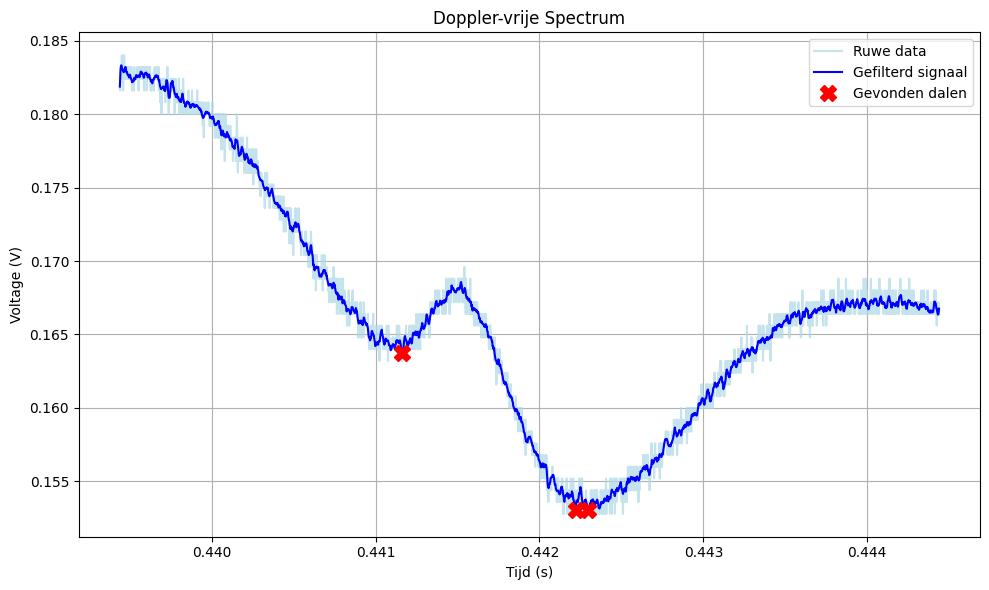


Tijdstippen van de gevonden dalen (s):
Dal 1: 0.441160 s
Dal 2: 0.442220 s
Dal 3: 0.442296 s


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

file_ch1 = 's2.CSV'

df_ch1 = pd.read_csv(file_ch1, header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])


tijd = df_ch1['Tijd'].values
signaal = df_ch1['Voltage'].values


signaal_smoothed = savgol_filter(signaal, window_length=15, polyorder=3)


inv_signaal = -signaal_smoothed


pieken_indices, eigenschappen = find_peaks(inv_signaal, prominence=0.002, width=5)

tijd_dalen = tijd[pieken_indices]
voltage_dalen = signaal_smoothed[pieken_indices]

print(f"Aantal gevonden brede Doppler-dalen: {len(pieken_indices)}")

plt.figure(figsize=(10, 6))

plt.plot(tijd, signaal, label='Ruwe data', color='lightblue', alpha=0.7)
plt.plot(tijd, signaal_smoothed, label='Gefilterd signaal', color='blue')
plt.plot(tijd_dalen, voltage_dalen, 'X', color='red', markersize=12, label='Gevonden dalen')

plt.title('Doppler-vrije Spectrum')
plt.xlabel('Tijd (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()


plt.show()


print("\nTijdstippen van de gevonden dalen (s):")
for i, t in enumerate(tijd_dalen):
    print(f"Dal {i + 1}: {t:.6f} s")

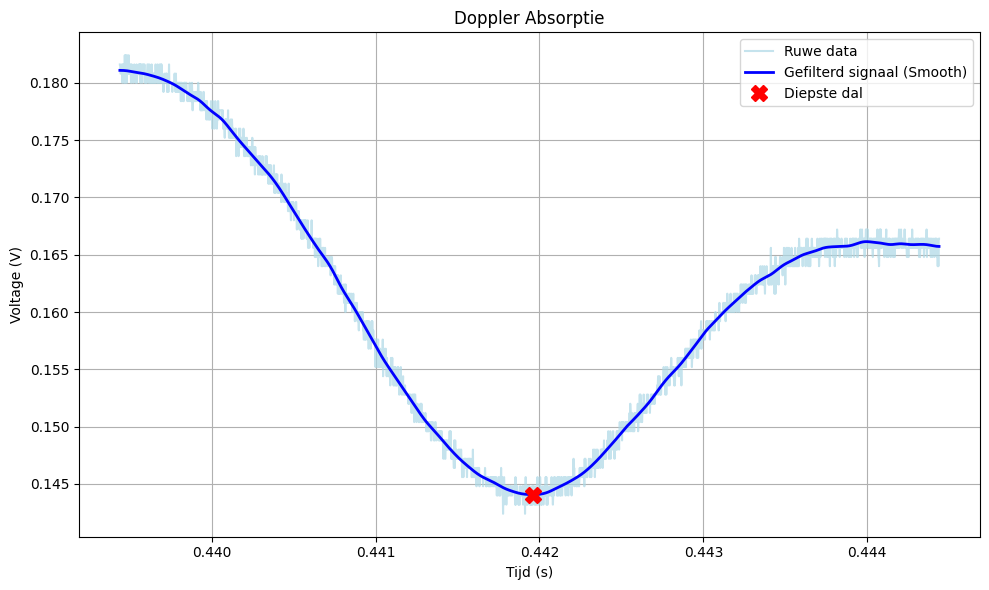

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d


df_vrij = pd.read_csv('d2.CSV', header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])

tijd = df_vrij['Tijd'].values
signaal = df_vrij['Voltage'].values


signaal_smoothed = gaussian_filter1d(signaal, sigma=20)


inv_signaal = -signaal_smoothed
pieken_indices, _ = find_peaks(inv_signaal, prominence=0.001, width=20)

if len(pieken_indices) > 0:
    diepste_dal_index = pieken_indices[np.argmin(signaal_smoothed[pieken_indices])]
    tijd_dal = tijd[diepste_dal_index]
    voltage_dal = signaal_smoothed[diepste_dal_index]
else:
    tijd_dal, voltage_dal = [], []

plt.figure(figsize=(10, 6))
plt.plot(tijd, signaal, label='Ruwe data', color='lightblue', alpha=0.7)
plt.plot(tijd, signaal_smoothed, label='Gefilterd signaal (Smooth)', color='blue', linewidth=2)

if len(pieken_indices) > 0:
    plt.plot(tijd_dal, voltage_dal, 'X', color='red', markersize=12, label='Diepste dal')

plt.title('Doppler Absorptie')
plt.xlabel('Tijd (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

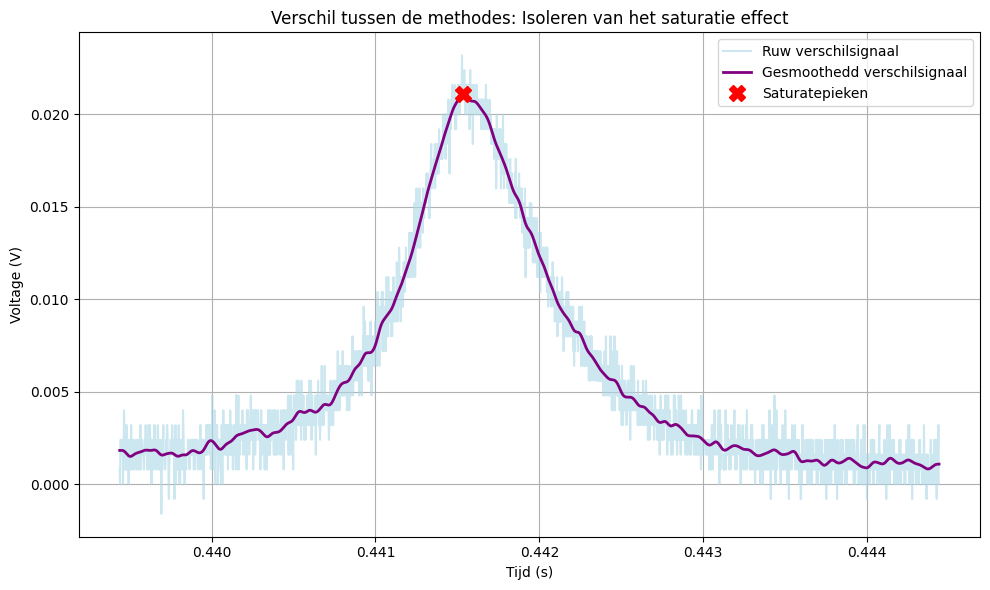

Aantal gevonden saturatiepieken: 1

Tijdstippen van de pieken:
Piek 1: 0.441536 s


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d


df_doppler = pd.read_csv('s2.CSV', header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])
df_vrij = pd.read_csv('d2.CSV', header=None, usecols=[3, 4], names=['Tijd', 'Voltage'])

tijd = df_doppler['Tijd'].values
signaal_doppler = df_doppler['Voltage'].values
signaal_vrij = df_vrij['Voltage'].values

verschil_ruw = signaal_doppler - signaal_vrij

verschil_smoothed = gaussian_filter1d(verschil_ruw, sigma=10)

pieken_indices, _ = find_peaks(verschil_smoothed, prominence=0.001)

tijd_pieken = tijd[pieken_indices]
voltage_pieken = verschil_smoothed[pieken_indices]

plt.figure(figsize=(10, 6))

plt.plot(tijd, verschil_ruw, label='Ruw verschilsignaal', color='lightblue', alpha=0.6)
plt.plot(tijd, verschil_smoothed, label='Gesmoothedd verschilsignaal', color='purple', linewidth=2)

if len(pieken_indices) > 0:
    plt.plot(tijd_pieken, voltage_pieken, 'X', color='red', markersize=12, label='Saturatepieken')

plt.title('Verschil tussen de methodes: Isoleren van het saturatie effect')
plt.xlabel('Tijd (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if len(pieken_indices) > 0:
    print(f"Aantal gevonden saturatiepieken: {len(pieken_indices)}\n")
    print("Tijdstippen van de pieken:")
    for i, t in enumerate(tijd_pieken):
        print(f"Piek {i + 1}: {t:.6f} s")
else:
    print("Geen duidelijke piek gevonden, probeer de prominence aan te passen.")